In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv('educational_service_long.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43442 entries, 0 to 43441
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   custid     43442 non-null  int64
 1   startlen   43442 non-null  int64
 2   time       43442 non-null  int64
 3   payleft    43442 non-null  int64
 4   lagtest    43442 non-null  int64
 5   cancelnow  43442 non-null  int64
dtypes: int64(6)
memory usage: 2.0 MB


In [8]:
df

,custid,startlen,time,payleft,lagtest,cancelnow
0,137,6,1,5,4,0
1,137,6,2,4,4,0
2,137,6,3,3,4,0
3,137,6,4,2,4,0
4,137,6,5,1,4,0
...,...,...,...,...,...,...
43437,11392,6,9,3,4,0
43438,11392,6,10,2,4,0
43439,11392,6,11,1,4,0
43440,11786,6,1,5,0,0


# Part I
Create a chart with the survival function and a chart with the hazard function. Your chart should merely describe the data. That is, do not model the data (i.e., do not impose a functional form), but compute summary statistics that describe the percentage of customers retained (i.e., survival function) and defection probabilities (i.e., hazard function) over time. Plot customers with different levels of startlen separately.

In [10]:
df.columns = df.columns.str.strip().str.lower()

# Grouping the data by startlen and time (months)
data = df.groupby(['startlen', 'time']).agg(
    defect=('cancelnow', 'sum'),         
    customers=('custid', 'nunique')     
).reset_index()

# Calculating hazard rate 
data['hazard_rate'] = data['defect'] / data['customers']

data['cum_defect'] = data.groupby('startlen')['defect'].cumsum()
data['initial_customers'] = data.groupby('startlen')['customers'].transform('max')

# Calculating survival rate
data['survival_rate'] = (data['initial_customers'] - data['cum_defect']) / data['initial_customers']


In [12]:
data

,startlen,time,defect,customers,hazard_rate,cum_defect,initial_customers,survival_rate
0,1,1,20,2256,0.008865,20,2256,0.991135
1,1,2,76,2236,0.033989,96,2256,0.957447
2,1,3,157,2160,0.072685,253,2256,0.887855
3,1,4,108,2003,0.053919,361,2256,0.839982
4,1,5,128,1895,0.067546,489,2256,0.783245
5,1,6,138,1767,0.078098,627,2256,0.722074
6,1,7,130,1629,0.079804,757,2256,0.664450
7,1,8,99,1499,0.066044,856,2256,0.620567
8,1,9,64,1400,0.045714,920,2256,0.592199
9,1,10,58,1336,0.043413,978,2256,0.566489


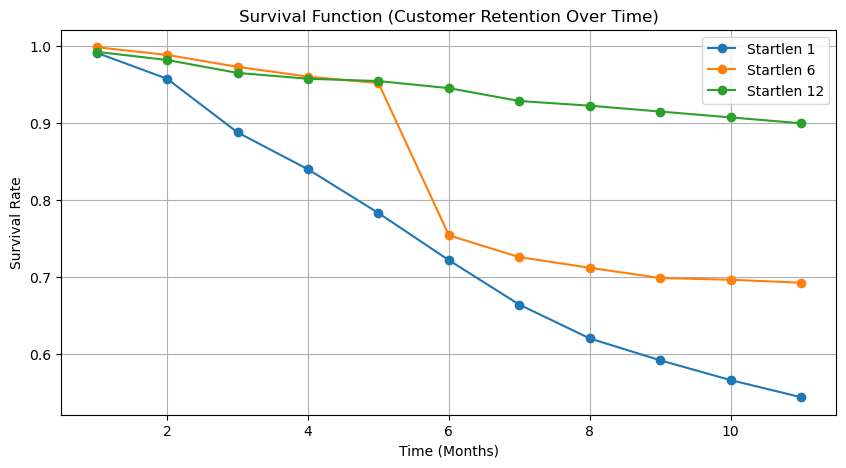

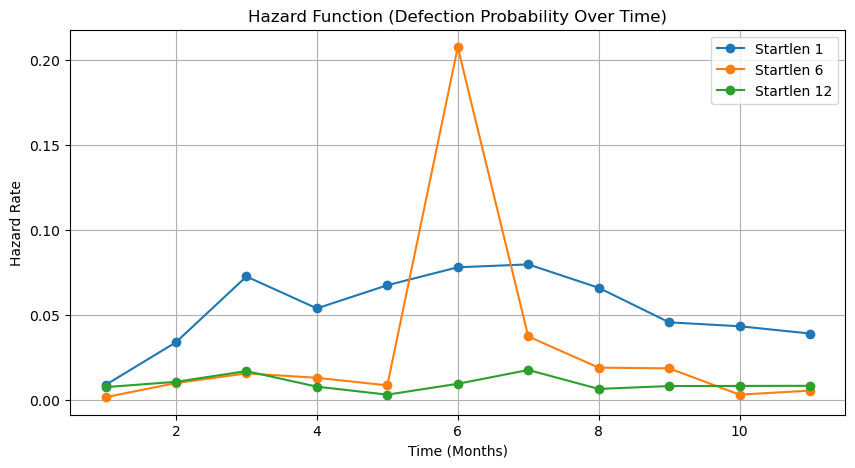

In [14]:
plt.figure(figsize=(10, 5))
for startlen, df_surv in data.groupby("startlen"):
    plt.plot(df_surv['time'], df_surv['survival_rate'], marker='o', linestyle='-', label=f'Startlen {startlen}')
plt.xlabel("Time (Months)")
plt.ylabel("Survival Rate")
plt.title("Survival Function (Customer Retention Over Time)")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
for startlen, df_haz in data.groupby("startlen"):
    plt.plot(df_haz['time'], df_haz['hazard_rate'], marker='o', linestyle='-', label=f'Startlen {startlen}')
plt.xlabel("Time (Months)")
plt.ylabel("Hazard Rate")
plt.title("Hazard Function (Defection Probability Over Time)")
plt.legend()
plt.grid()
plt.show()

# Part II
You will analyze survival curves and hazard probabilities as a function of trigger events. A trigger event is something that happens during a customer’s lifecycle that the company can detect and affects consumer behavior (here, churn). Specifically, the company wants to examine the following trigger events:
- The student has submitted at least once in previous month. [HINT: Create a dummy variable “lagtest_prevmonth” based on “lagtest”: whether a customer submitted at least one exercise in the previous month (1) or not (0)]
- The student performs poorly on exercises, indicating that the student is either struggling with the material or not committing sufficient energy to the materials (low involvement). [HINT: Create a continuous variable “cumlagtest” based on “lagtest” that indicates the total or cumulative number of exercises a student submitted in the previous months.]
- The student’s current contract has just expired. [HINT: Create a dummy variable “contractup” based on “payleft” that indicates whether a student’s contract has just expired (1) or not (0).]

Use logistic regression analysis to examine the role of these trigger events. That is, (1) estimate a model that includes the original variables as well as the trigger variables. (tip: use ‘Time’ as a categorical variable) (2) Interpret the results from the model. What are the managerial insights? (3) Visualize your model-based hazard rate and survival rate. (4) How does your model perform? Are your model-based predictions close to the raw data? (Tip: ROC and AUC, when select optimal threshold, use the balanced approach min Type I + Type II)

In [16]:
# dummy variables

df['lagtest_prevmonth'] = (df['lagtest'] > 0).astype(int)
df['cumlagtest'] = df.groupby('custid')['lagtest'].cumsum()
df['contractup'] = (df['payleft'] == 0).astype(int)

# Logistic Regression

In [38]:
# Fitting logistic regression model
mod1 = smf.logit('cancelnow ~ payleft + lagtest + lagtest_prevmonth + startlen + cumlagtest + contractup + C(time)', data=df).fit()
print(mod1.summary())

Optimization terminated successfully.
         Current function value: 0.114726
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:              cancelnow   No. Observations:                43442
Model:                          Logit   Df Residuals:                    43425
Method:                           MLE   Df Model:                           16
Date:                Sun, 23 Mar 2025   Pseudo R-squ.:                  0.2892
Time:                        21:00:20   Log-Likelihood:                -4983.9
converged:                       True   LL-Null:                       -7011.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -5.6397      0.255    -22.120      0.000      -6.139      -5.140
C(time)

In [21]:
# Computing hazard rate predictions using our logistic regression model
df['hazard_rate_pred'] = mod1.predict(df)  

df['survival_rate_pred'] = np.nan
cust_ids = df['custid'].unique()

# computing survival rate
for cust in cust_ids:
    temp = df[df['custid'] == cust].sort_values(by='time').copy()

    temp.loc[temp.index[0], 'survival_rate_pred'] = 1 - temp.iloc[0]['hazard_rate_pred']

    for i in range(1, len(temp)):
        prev_survival = temp.iloc[i-1]['survival_rate_pred']
        hazard = temp.iloc[i]['hazard_rate_pred']
        temp.loc[temp.index[i], 'survival_rate_pred'] = prev_survival * (1 - hazard)

    df.loc[temp.index, 'survival_rate_pred'] = temp['survival_rate_pred']

df[['custid', 'time', 'hazard_rate_pred', 'survival_rate_pred']].head(10)

,custid,time,hazard_rate_pred,survival_rate_pred
0,137,1,0.000324,0.999676
1,137,2,0.000934,0.998743
2,137,3,0.001747,0.996998
3,137,4,0.000978,0.996023
4,137,5,0.000977,0.995049
5,137,6,0.019305,0.975840
6,137,7,0.035546,0.941153
7,137,8,0.001126,0.940093
8,137,9,0.000784,0.939356
9,137,10,0.000617,0.938776


In [22]:
# Aggregating mean hazard and survival rates by startlen and time
agg_data = df.groupby(['startlen', 'time']).agg({
    'hazard_rate_pred': 'mean',
    'survival_rate_pred': 'mean'
}).reset_index()

agg_data

,startlen,time,hazard_rate_pred,survival_rate_pred
0,1,1,0.010397,0.989603
1,1,2,0.037771,0.952910
2,1,3,0.074046,0.888614
3,1,4,0.054354,0.857376
4,1,5,0.060145,0.823822
5,1,6,0.112976,0.758900
6,1,7,0.091878,0.726763
7,1,8,0.065298,0.717545
8,1,9,0.049609,0.714967
9,1,10,0.036974,0.712098


In [25]:
# Merging actual hazard_rate and survival_rate into agg_data
agg_data = agg_data.merge(
    data[['startlen', 'time', 'hazard_rate', 'survival_rate']],
    on=['startlen', 'time'],
    how='left'
)

agg_data

,startlen,time,hazard_rate_pred,survival_rate_pred,hazard_rate,survival_rate
0,1,1,0.010397,0.989603,0.008865,0.991135
1,1,2,0.037771,0.952910,0.033989,0.957447
2,1,3,0.074046,0.888614,0.072685,0.887855
3,1,4,0.054354,0.857376,0.053919,0.839982
4,1,5,0.060145,0.823822,0.067546,0.783245
5,1,6,0.112976,0.758900,0.078098,0.722074
6,1,7,0.091878,0.726763,0.079804,0.664450
7,1,8,0.065298,0.717545,0.066044,0.620567
8,1,9,0.049609,0.714967,0.045714,0.592199
9,1,10,0.036974,0.712098,0.043413,0.566489


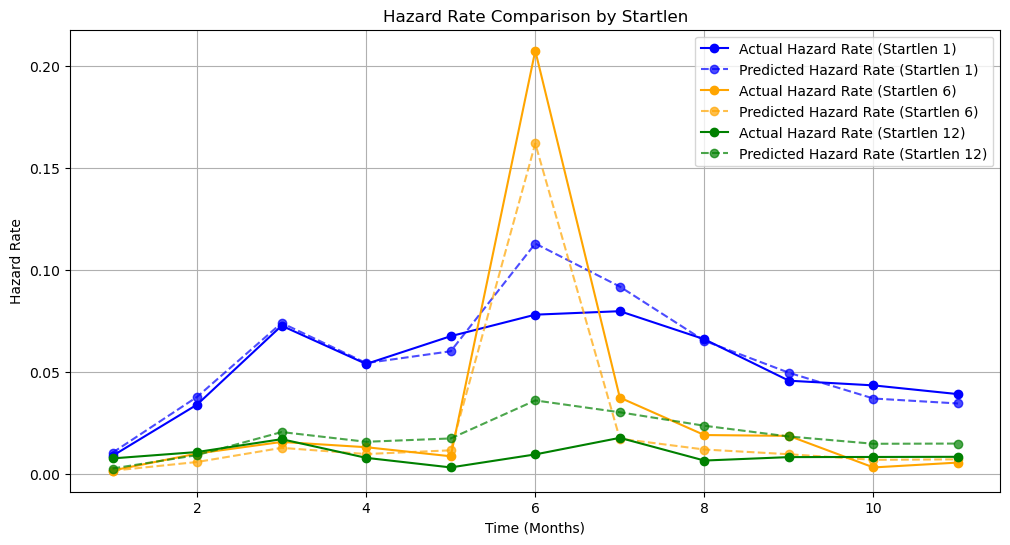

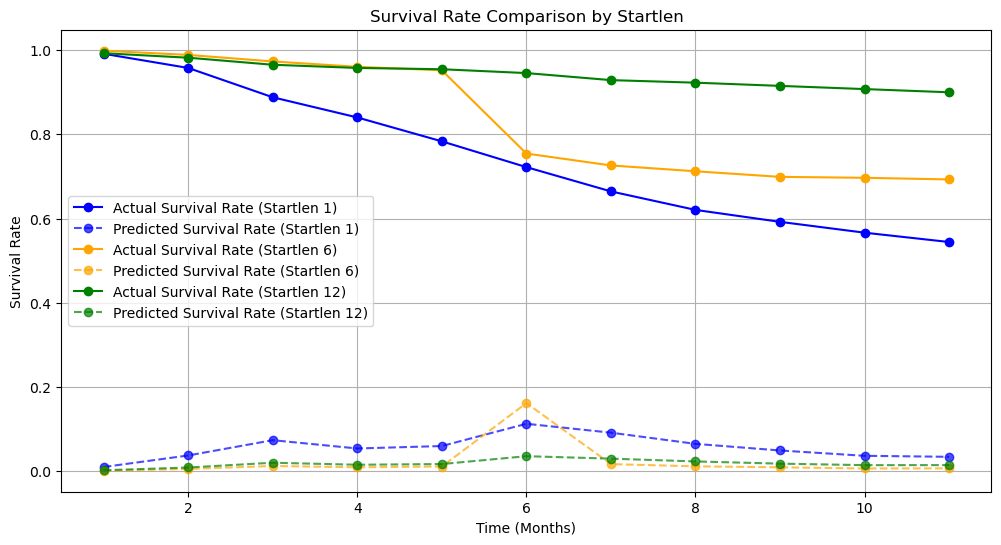

In [27]:
import matplotlib.pyplot as plt

colors = {1: 'blue', 6: 'orange', 12: 'green'}  

plt.figure(figsize=(12, 6))

for startlen in [1, 6, 12]:
    subset = agg_data[agg_data['startlen'] == startlen]

    plt.plot(subset['time'], subset['hazard_rate'], 'o-', 
             label=f"Actual Hazard Rate (Startlen {startlen})", 
             color=colors[startlen])

    plt.plot(subset['time'], subset['hazard_rate_pred'], 'o--', 
             label=f"Predicted Hazard Rate (Startlen {startlen})", 
             color=colors[startlen], alpha=0.7)  # Slight transparency for better differentiation

plt.title("Hazard Rate Comparison by Startlen")
plt.xlabel("Time (Months)")
plt.ylabel("Hazard Rate")
plt.legend()
plt.grid(True)
plt.show()

# Creating the survival rate plot
plt.figure(figsize=(12, 6))

for startlen in [1, 6, 12]:
    subset = agg_data[agg_data['startlen'] == startlen]

    plt.plot(subset['time'], subset['survival_rate'], 'o-', 
             label=f"Actual Survival Rate (Startlen {startlen})", 
             color=colors[startlen])

    plt.plot(subset['time'], subset['hazard_rate_pred'], 'o--', 
             label=f"Predicted Survival Rate (Startlen {startlen})", 
             color=colors[startlen], alpha=0.7)

plt.title("Survival Rate Comparison by Startlen")
plt.xlabel("Time (Months)")
plt.ylabel("Survival Rate")
plt.legend()
plt.grid(True)
plt.show()


AUC Score: 0.8943


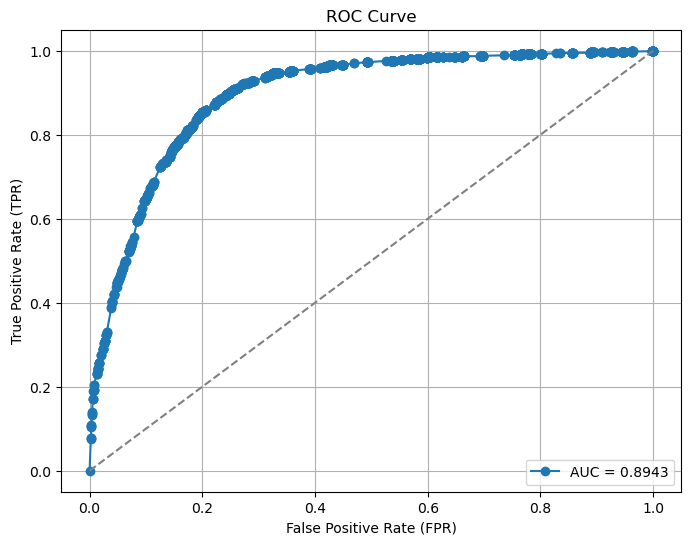

In [29]:
df['pred_prob'] = mod1.predict(df)

from sklearn.metrics import roc_curve, roc_auc_score

y_true = df['cancelnow']           
y_scores = df['pred_prob']        

# Computing ROC curve values
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# Computing AUC scores
auc_score = roc_auc_score(y_true, y_scores)
print(f"AUC Score: {auc_score:.4f}")  

# Plotting ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, marker='o', label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [31]:
df

,custid,startlen,time,payleft,lagtest,cancelnow,lagtest_prevmonth,cumlagtest,contractup,hazard_rate_pred,survival_rate_pred,pred_prob
0,137,6,1,5,4,0,1,4,0,0.000324,0.999676,0.000324
1,137,6,2,4,4,0,1,8,0,0.000934,0.998743,0.000934
2,137,6,3,3,4,0,1,12,0,0.001747,0.996998,0.001747
3,137,6,4,2,4,0,1,16,0,0.000978,0.996023,0.000978
4,137,6,5,1,4,0,1,20,0,0.000977,0.995049,0.000977
...,...,...,...,...,...,...,...,...,...,...,...,...
43437,11392,6,9,3,4,0,1,36,0,0.000714,0.972612,0.000714
43438,11392,6,10,2,4,0,1,40,0,0.000562,0.972065,0.000562
43439,11392,6,11,1,4,0,1,44,0,0.000471,0.971608,0.000471
43440,11786,6,1,5,0,0,0,0,0,0.007525,0.992475,0.007525


In [42]:
from sklearn.metrics import confusion_matrix, classification_report

# finding optimal threshold
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (Balanced Approach): {optimal_threshold:.4f}")

df['pred_class'] = (df['pred_prob'] >= optimal_threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(df['cancelnow'], df['pred_class'])

print("Confusion Matrix:")
print(cm)

# Classification Report for Precision, Recall, and F1-score
print("\nClassification Report:")
print(classification_report(df['cancelnow'], df['pred_class']))


Optimal Threshold (Balanced Approach): 0.0419
Confusion Matrix:
[[33433  8360]
 [  241  1408]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.80      0.89     41793
           1       0.14      0.85      0.25      1649

    accuracy                           0.80     43442
   macro avg       0.57      0.83      0.57     43442
weighted avg       0.96      0.80      0.86     43442



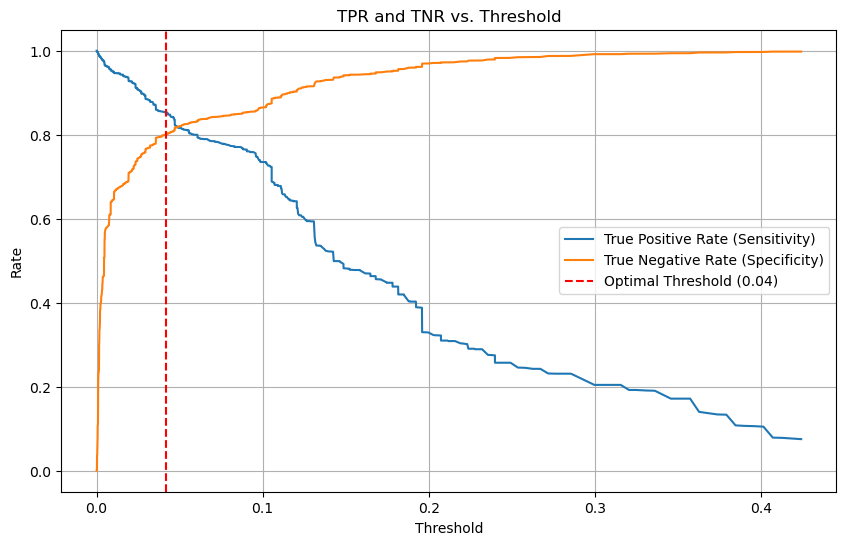

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, tpr, label='True Positive Rate (Sensitivity)')
plt.plot(thresholds, 1 - fpr, label='True Negative Rate (Specificity)')
plt.axvline(optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Rate')
plt.title('TPR and TNR vs. Threshold')
plt.legend()
plt.grid(True)
plt.show()